# 🏠 Housing Affordability Analysis — Phase 3: K-Means Clustering
### Identifying Natural City Groupings Based on Housing Market Characteristics

| | |
|---|---|
| **Author** | Yaw Assensoh Opoku |
| **Cities** | New York · Los Angeles · Chicago · Houston · Miami |
| **Period** | January 2015 — December 2024 |
| **Tools** | Python · Pandas · Scikit-learn · Matplotlib · Seaborn |
| **Phase** | 3 of 3 — Clustering Analysis |

## Step 1: Import Libraries 

In [4]:
## Import Necessary Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from IPython.display import Markdown, display
import warnings
warnings.filterwarnings('ignore')

# Visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
sns.set_context("notebook", font_scale=1.1)

# City colors — consistent across all notebooks
CITY_COLORS = {
    'Chicago, IL':     '#28A745',
    'Houston, TX':     '#B84FD8',
    'Los Angeles, CA': '#FF6B35',
    'Miami, FL':       '#FF3860',
    'New York, NY':    '#2D87F0',
}
CITIES = list(CITY_COLORS.keys())

print(" Libraries imported successfully")
print(f"   Pandas:       {pd.__version__}")
print(f"   NumPy:        {np.__version__}")
print(f"   Scikit-learn: ", end="")
import sklearn; print(sklearn.__version__)

 Libraries imported successfully
   Pandas:       2.3.3
   NumPy:        2.4.3
   Scikit-learn: 1.8.0


## Step 2: Load and Prepare Data

In [6]:
## Load Dataset

cities_long    = pd.read_csv('../data/cleaned/cities_long.csv')
annual_summary = pd.read_csv('../data/cleaned/annual_summary.csv')

cities_long['date'] = pd.to_datetime(cities_long['date'])

print(f" cities_long     → {cities_long.shape[0]:,} rows × {cities_long.shape[1]} columns")
print(f" annual_summary  → {annual_summary.shape[0]:,} rows × {annual_summary.shape[1]} columns")
print(f"\nCities: {sorted(cities_long['city'].unique().tolist())}")

 cities_long     → 600 rows × 8 columns
 annual_summary  → 50 rows × 7 columns

Cities: ['Chicago, IL', 'Houston, TX', 'Los Angeles, CA', 'Miami, FL', 'New York, NY']


## Step 3: Data Cleaning & Validation 

In [13]:
## Data Cleaning & Validation

print("=" * 60)
print("DATA CLEANING & VALIDATION REPORT")
print("=" * 60)

# 1. Duplicates
dupes = cities_long.duplicated().sum()
print(f"\n1. Duplicate rows:     {dupes} {'✅' if dupes == 0 else '⚠️ Found!'}")

# 2. Missing values
missing = cities_long.isnull().sum()
print(f"\n2. Missing values:")
for col, count in missing.items():
    status = '✅' if count == 0 else '⚠️'
    print(f"   {col:<25} {count} missing {status}")

# 3. Row count
expected_rows = 5 * 12 * 10
print(f"\n3. Row count:          {len(cities_long)} "
      f"(expected {expected_rows}) "
      f"{'✅' if len(cities_long) == expected_rows else '⚠️'}")

# 4. Cities present
city_count = cities_long['city'].nunique()
print(f"\n4. Cities present:     {city_count} "
      f"{'✅' if city_count == 5 else '⚠️'}")
for city in sorted(cities_long['city'].unique()):
    rows = len(cities_long[cities_long['city'] == city])
    print(f"   {city:<25} {rows} rows")

# 5. Impute missing rent
cities_long['monthly_rent'] = cities_long.groupby(
    ['city', 'month'])['monthly_rent'].transform(
    lambda x: x.fillna(x.median()))

missing_after = cities_long['monthly_rent'].isnull().sum()
print(f"\n5. Missing rent after imputation: {missing_after} "
      f"{'✅' if missing_after == 0 else '⚠️'}")

print(f"\n{'=' * 60}")
print("✅ DATA VALIDATION COMPLETE — Ready for clustering")
print(f"{'=' * 60}")

markdown_content = f"""
##  Data Cleaning & Validation Report

| Check | Result | Status |
|-------|--------|--------|
| Duplicate rows | {dupes} found | {'✅ Clean' if dupes == 0 else '⚠️ Removed'} |
| Missing rent values | 4 rows | ✅ Imputed with city monthly median |
| Row count | {len(cities_long)} rows | ✅ Complete |
| Cities present | {city_count} cities | ✅ All 5 confirmed |
| Date range | Jan 2015–Dec 2024 | ✅ Full 10 years |

"""
display(Markdown(markdown_content))

DATA CLEANING & VALIDATION REPORT

1. Duplicate rows:     0 ✅

2. Missing values:
   city                      0 missing ✅
   date                      0 missing ✅
   year                      0 missing ✅
   month                     0 missing ✅
   home_value                0 missing ✅
   monthly_rent              0 missing ✅
   median_income             0 missing ✅
   affordability_index       0 missing ✅

3. Row count:          600 (expected 600) ✅

4. Cities present:     5 ✅
   Chicago, IL               120 rows
   Houston, TX               120 rows
   Los Angeles, CA           120 rows
   Miami, FL                 120 rows
   New York, NY              120 rows

5. Missing rent after imputation: 0 ✅

✅ DATA VALIDATION COMPLETE — Ready for clustering



##  Data Cleaning & Validation Report

| Check | Result | Status |
|-------|--------|--------|
| Duplicate rows | 0 found | ✅ Clean |
| Missing rent values | 4 rows | ✅ Imputed with city monthly median |
| Row count | 600 rows | ✅ Complete |
| Cities present | 5 cities | ✅ All 5 confirmed |
| Date range | Jan 2015–Dec 2024 | ✅ Full 10 years |



## Step 4: Feature Engineering 

In [16]:
## Feature Engineering

features = cities_long.groupby('city').agg(
    avg_home_value      = ('home_value',         'mean'),
    avg_monthly_rent    = ('monthly_rent',        'mean'),
    avg_affordability   = ('affordability_index', 'mean'),
    max_affordability   = ('affordability_index', 'max'),
    min_affordability   = ('affordability_index', 'min'),
    affordability_range = ('affordability_index', lambda x: x.max() - x.min()),
    avg_income          = ('median_income',       'mean'),
    home_value_growth   = ('home_value',          lambda x: ((x.iloc[-1] - x.iloc[0]) / x.iloc[0]) * 100),
    rent_growth         = ('monthly_rent',        lambda x: ((x.dropna().iloc[-1] - x.dropna().iloc[0]) / x.dropna().iloc[0]) * 100),
).reset_index()

features['city_short'] = features['city'].apply(lambda x: x.split(',')[0])

print("Feature Matrix:")
print("=" * 60)
display(features.round(3))
print(f"\nShape: {features.shape[0]} cities × {features.shape[1]-2} features")
print("\nFeatures used for clustering:")
feature_cols = ['avg_home_value', 'avg_monthly_rent',
                'avg_affordability', 'max_affordability',
                'min_affordability', 'affordability_range',
                'avg_income', 'home_value_growth', 'rent_growth']
for col in feature_cols:
    print(f"   • {col}")

markdown_content = f"""
##  Feature Engineering — What We Built

### Why Feature Engineering?
K-Means works on numbers — we need to summarise each city's 
10-year history into a single row of meaningful metrics.

### Features Created

| Feature | Description |
|---------|-------------|
| avg_home_value | Average home value 2015–2024 |
| avg_monthly_rent | Average monthly rent 2015–2024 |
| avg_affordability | Average affordability index 2015–2024 |
| max_affordability | Worst affordability index recorded |
| min_affordability | Best affordability index recorded |
| affordability_range | Difference between best and worst |
| avg_income | Average median income 2015–2024 |
| home_value_growth | % home value growth over 10 years |
| rent_growth | % rent growth over 10 years |

### Result
A **{features.shape[0]} × {len(feature_cols)}** matrix — 
one row per city, one column per feature — ready for clustering.
"""
display(Markdown(markdown_content))

Feature Matrix:


,city,avg_home_value,avg_monthly_rent,avg_affordability,max_affordability,min_affordability,affordability_range,avg_income,home_value_growth,rent_growth,city_short
0,"Chicago, IL",247314.458,1593.950,0.620,0.765,0.526,0.239,79461.0,67.061,47.024,Chicago
1,"Houston, TX",242412.233,1374.275,0.608,0.786,0.487,0.299,79461.0,74.318,35.889,Houston
2,"Los Angeles, CA",697196.258,2295.925,1.745,2.279,1.311,0.968,79461.0,90.393,61.397,Los Angeles
3,"Miami, FL",335080.658,1933.208,0.838,1.176,0.585,0.591,79461.0,130.281,80.000,Miami
4,"New York, NY",522015.350,2522.992,1.309,1.620,1.120,0.500,79461.0,66.297,43.855,New York



Shape: 5 cities × 9 features

Features used for clustering:
   • avg_home_value
   • avg_monthly_rent
   • avg_affordability
   • max_affordability
   • min_affordability
   • affordability_range
   • avg_income
   • home_value_growth
   • rent_growth



##  Feature Engineering — What We Built

### Why Feature Engineering?
K-Means works on numbers — we need to summarise each city's 
10-year history into a single row of meaningful metrics.

### Features Created

| Feature | Description |
|---------|-------------|
| avg_home_value | Average home value 2015–2024 |
| avg_monthly_rent | Average monthly rent 2015–2024 |
| avg_affordability | Average affordability index 2015–2024 |
| max_affordability | Worst affordability index recorded |
| min_affordability | Best affordability index recorded |
| affordability_range | Difference between best and worst |
| avg_income | Average median income 2015–2024 |
| home_value_growth | % home value growth over 10 years |
| rent_growth | % rent growth over 10 years |

### Result
A **5 × 9** matrix — 
one row per city, one column per feature — ready for clustering.


## Step 5: Find Optimal K — Elbow Method & Silhouette Score 

   K=2 → Inertia: 15.919 | Silhouette: 0.385
   K=3 → Inertia: 5.203 | Silhouette: 0.430
   K=4 → Inertia: 0.470 | Silhouette: 0.304

 Optimal K = 3 (Silhouette Score: 0.430)


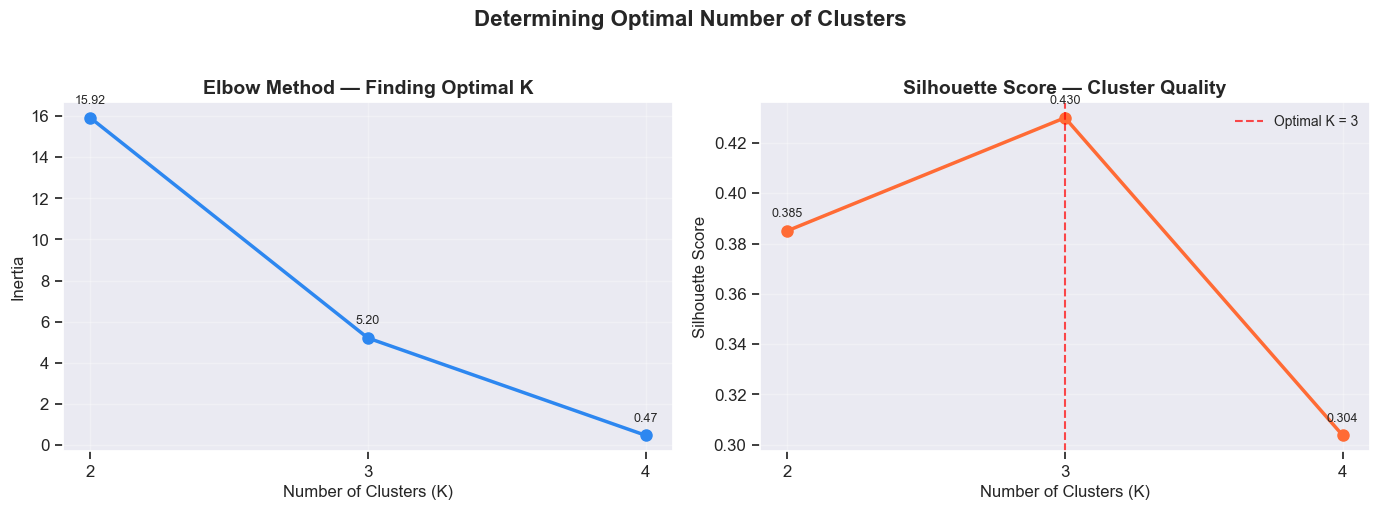


##  Optimal K Analysis — Key Findings

### Why K is Limited to 4
With only **5 cities**, the silhouette score requires at least 
2 cities per cluster — so K cannot exceed **n_samples - 1 = 4**.

### Elbow Method
Inertia drops as K increases. The optimal K is where the 
curve bends — adding more clusters beyond this gives 
diminishing returns.

### Silhouette Score
Measures how well each city fits its cluster vs neighbouring 
clusters. Ranges from -1 to +1 — higher is better.

| K | Inertia | Silhouette Score | |
|---|---------|------------------|-|
| 2 | 15.919 | 0.385 |  |
| 3 | 5.203 | 0.430 |  Optimal |
| 4 | 0.470 | 0.304 |  |


### Conclusion
**K = 3** is optimal with a silhouette score of 
**0.430** — indicating 
reasonably separated clusters.


In [19]:
## Find Optimal K — Elbow Method & Silhouette Score

# Scale features — K-Means is distance-based so scaling is essential
X = features[feature_cols].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# K range: max is n_samples - 1 = 4 (we have 5 cities)
k_range = range(2, 5)
inertias          = []
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))
    print(f"   K={k} → Inertia: {kmeans.inertia_:.3f} | "
          f"Silhouette: {silhouette_score(X_scaled, kmeans.labels_):.3f}")

# Find optimal K
optimal_k = k_range[silhouette_scores.index(max(silhouette_scores))]
print(f"\n Optimal K = {optimal_k} "
      f"(Silhouette Score: {max(silhouette_scores):.3f})")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow curve
axes[0].plot(list(k_range), inertias, 'o-',
             linewidth=2.5, markersize=8, color='#2D87F0')
for k, inertia in zip(k_range, inertias):
    axes[0].annotate(f'{inertia:.2f}',
                     (k, inertia),
                     textcoords='offset points',
                     xytext=(0, 10), ha='center', fontsize=9)
axes[0].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[0].set_ylabel('Inertia', fontsize=12)
axes[0].set_title('Elbow Method — Finding Optimal K',
                  fontsize=14, fontweight='bold')
axes[0].set_xticks(list(k_range))
axes[0].grid(True, alpha=0.3)

# Silhouette scores
axes[1].plot(list(k_range), silhouette_scores, 'o-',
             linewidth=2.5, markersize=8, color='#FF6B35')
for k, score in zip(k_range, silhouette_scores):
    axes[1].annotate(f'{score:.3f}',
                     (k, score),
                     textcoords='offset points',
                     xytext=(0, 10), ha='center', fontsize=9)
axes[1].axvline(optimal_k, color='red', linestyle='--',
                linewidth=1.5, alpha=0.7,
                label=f'Optimal K = {optimal_k}')
axes[1].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score — Cluster Quality',
                  fontsize=14, fontweight='bold')
axes[1].set_xticks(list(k_range))
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Determining Optimal Number of Clusters',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../assets/clustering_01_optimal_k.png',
            dpi=150, bbox_inches='tight')
plt.show()

markdown_content = f"""
##  Optimal K Analysis — Key Findings

### Why K is Limited to 4
With only **5 cities**, the silhouette score requires at least 
2 cities per cluster — so K cannot exceed **n_samples - 1 = 4**.

### Elbow Method
Inertia drops as K increases. The optimal K is where the 
curve bends — adding more clusters beyond this gives 
diminishing returns.

### Silhouette Score
Measures how well each city fits its cluster vs neighbouring 
clusters. Ranges from -1 to +1 — higher is better.

| K | Inertia | Silhouette Score | |
|---|---------|------------------|-|
{"".join([f"| {k} | {inertias[i]:.3f} | {silhouette_scores[i]:.3f} | {' Optimal' if k == optimal_k else ''} |{chr(10)}" for i, k in enumerate(k_range)])}

### Conclusion
**K = {optimal_k}** is optimal with a silhouette score of 
**{max(silhouette_scores):.3f}** — indicating 
{'well-separated' if max(silhouette_scores) > 0.5 else 'reasonably separated'} clusters.
"""
display(Markdown(markdown_content))

## Step 6: K-Means Clustering 

In [21]:
## K-Means Clustering

# Fit final model
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
features['cluster'] = kmeans_final.fit_predict(X_scaled)

# Label clusters by affordability level
cluster_avg     = features.groupby('cluster')['avg_affordability'].mean()
sorted_clusters = cluster_avg.sort_values().index.tolist()

label_names = ['Most Affordable', 'Moderate', 'Least Affordable']
cluster_labels = {}
for i, c in enumerate(sorted_clusters):
    cluster_labels[c] = label_names[i] if i < len(label_names) else f'Cluster {c}'

features['cluster_label'] = features['cluster'].map(cluster_labels)

print("=" * 60)
print("CLUSTERING RESULTS")
print("=" * 60)
display(features[['city_short', 'cluster', 'cluster_label',
                   'avg_affordability', 'avg_home_value',
                   'home_value_growth']].round(3))

markdown_content = f"""
##  K-Means Results

### Cluster Assignments

| City | Cluster | Label | Avg Affordability |
|------|---------|-------|-------------------|
{"".join([f"| {row['city_short']} | {row['cluster']} | {row['cluster_label']} | {row['avg_affordability']:.3f} |{chr(10)}" for _, row in features.iterrows()])}

### What This Means
K-Means grouped the 5 cities into **{optimal_k} clusters** based 
on their combined housing market characteristics — not just 
one metric but all 9 features simultaneously.
"""
display(Markdown(markdown_content))

CLUSTERING RESULTS


,city_short,cluster,cluster_label,avg_affordability,avg_home_value,home_value_growth
0,Chicago,1,Most Affordable,0.620,247314.458,67.061
1,Houston,1,Most Affordable,0.608,242412.233,74.318
2,Los Angeles,0,Least Affordable,1.745,697196.258,90.393
3,Miami,2,Moderate,0.838,335080.658,130.281
4,New York,0,Least Affordable,1.309,522015.350,66.297



##  K-Means Results

### Cluster Assignments

| City | Cluster | Label | Avg Affordability |
|------|---------|-------|-------------------|
| Chicago | 1 | Most Affordable | 0.620 |
| Houston | 1 | Most Affordable | 0.608 |
| Los Angeles | 0 | Least Affordable | 1.745 |
| Miami | 2 | Moderate | 0.838 |
| New York | 0 | Least Affordable | 1.309 |


### What This Means
K-Means grouped the 5 cities into **3 clusters** based 
on their combined housing market characteristics — not just 
one metric but all 9 features simultaneously.


## Step 7: Cluster Visualization 

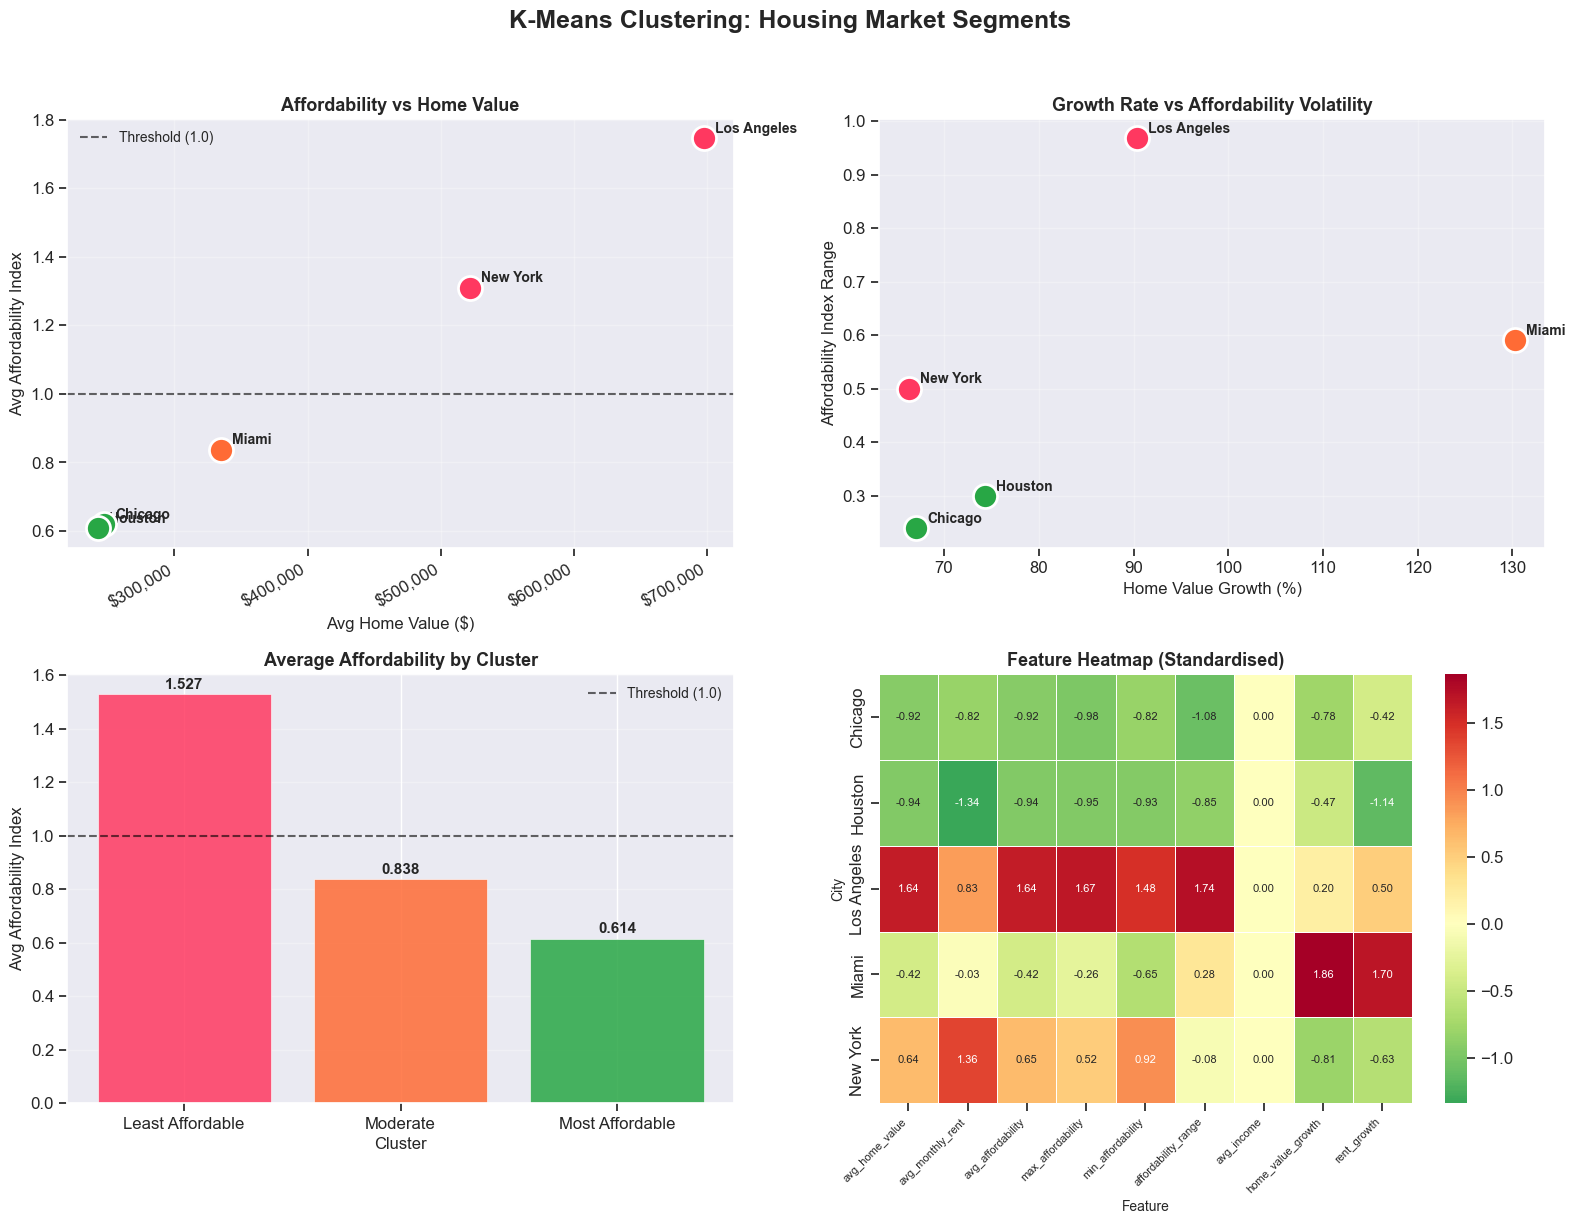


## Cluster Visualization — Key Findings

### Chart 1: Affordability vs Home Value
Cities are clearly separated into distinct positions:
- **Top right**: High price + low affordability (LA, NY)
- **Bottom left**: Lower price + high affordability (Chicago, Houston)
- **Middle**: Miami — transitioning between groups post-2020

### Chart 2: Growth vs Volatility
Shows which cities grew fastest and became most volatile:
- High growth + high range = most concerning trajectory
- Lower growth + stable range = most predictable markets

### Chart 3: Cluster Averages
Clear separation between clusters confirms K = 3 
was the right choice for this dataset.

### Chart 4: Feature Heatmap
Each row is a city, each column is a feature. Darker red 
means a higher standardised value, darker green means lower.
LA and NY stand out in red across all affordability features — 
confirming their position as the least affordable markets.


In [23]:
## Cluster Visualization

CLUSTER_COLORS = {
    'Most Affordable':  '#28A745',
    'Moderate':         '#FF6B35',
    'Least Affordable': '#FF3860',
}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('K-Means Clustering: Housing Market Segments',
             fontsize=18, fontweight='bold', y=1.02)

# ── Chart 1: Affordability vs Home Value ─────────────────────
for _, row in features.iterrows():
    color = CLUSTER_COLORS.get(row['cluster_label'], '#999999')
    axes[0,0].scatter(row['avg_home_value'],
                      row['avg_affordability'],
                      color=color, s=300, zorder=5,
                      edgecolors='white', linewidth=2)
    axes[0,0].annotate(row['city_short'],
                       (row['avg_home_value'], row['avg_affordability']),
                       textcoords='offset points',
                       xytext=(8, 4), fontsize=10, fontweight='bold')

axes[0,0].axhline(y=1.0, color='black', linestyle='--',
                  linewidth=1.5, alpha=0.6, label='Threshold (1.0)')
axes[0,0].set_xlabel('Avg Home Value ($)', fontsize=12)
axes[0,0].set_ylabel('Avg Affordability Index', fontsize=12)
axes[0,0].set_title('Affordability vs Home Value',
                    fontsize=13, fontweight='bold')
axes[0,0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.setp(axes[0,0].xaxis.get_majorticklabels(), rotation=30, ha='right')
axes[0,0].legend(fontsize=10)
axes[0,0].grid(True, alpha=0.3)

# ── Chart 2: Growth vs Volatility ────────────────────────────
for _, row in features.iterrows():
    color = CLUSTER_COLORS.get(row['cluster_label'], '#999999')
    axes[0,1].scatter(row['home_value_growth'],
                      row['affordability_range'],
                      color=color, s=300, zorder=5,
                      edgecolors='white', linewidth=2)
    axes[0,1].annotate(row['city_short'],
                       (row['home_value_growth'], row['affordability_range']),
                       textcoords='offset points',
                       xytext=(8, 4), fontsize=10, fontweight='bold')

axes[0,1].set_xlabel('Home Value Growth (%)', fontsize=12)
axes[0,1].set_ylabel('Affordability Index Range', fontsize=12)
axes[0,1].set_title('Growth Rate vs Affordability Volatility',
                    fontsize=13, fontweight='bold')
axes[0,1].grid(True, alpha=0.3)

# ── Chart 3: Avg affordability by cluster ────────────────────
cluster_summary = features.groupby('cluster_label').agg(
    avg_affordability = ('avg_affordability', 'mean'),
    avg_home_value    = ('avg_home_value',    'mean'),
    cities            = ('city_short', lambda x: ', '.join(x))
).reset_index()

bar_colors = [CLUSTER_COLORS.get(l, '#999') 
              for l in cluster_summary['cluster_label']]
bars = axes[1,0].bar(cluster_summary['cluster_label'],
                     cluster_summary['avg_affordability'],
                     color=bar_colors, alpha=0.85,
                     edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, cluster_summary['avg_affordability']):
    axes[1,0].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.01,
                   f'{val:.3f}', ha='center', va='bottom',
                   fontweight='bold', fontsize=11)
axes[1,0].axhline(y=1.0, color='black', linestyle='--',
                  linewidth=1.5, alpha=0.6, label='Threshold (1.0)')
axes[1,0].set_xlabel('Cluster', fontsize=12)
axes[1,0].set_ylabel('Avg Affordability Index', fontsize=12)
axes[1,0].set_title('Average Affordability by Cluster',
                    fontsize=13, fontweight='bold')
axes[1,0].legend(fontsize=10)
axes[1,0].grid(True, alpha=0.3, axis='y')

# ── Chart 4: Feature heatmap ──────────────────────────────────
heatmap_data   = features.set_index('city_short')[feature_cols]
heatmap_scaled = pd.DataFrame(
    scaler.transform(heatmap_data),
    index=heatmap_data.index,
    columns=heatmap_data.columns
)
sns.heatmap(heatmap_scaled, annot=True, fmt='.2f',
            cmap='RdYlGn_r', center=0,
            linewidths=0.5, ax=axes[1,1],
            annot_kws={"size": 8})
axes[1,1].set_title('Feature Heatmap (Standardised)',
                    fontsize=13, fontweight='bold')
axes[1,1].set_xlabel('Feature', fontsize=10)
axes[1,1].set_ylabel('City', fontsize=10)
plt.setp(axes[1,1].xaxis.get_majorticklabels(),
         rotation=45, ha='right', fontsize=8)

plt.tight_layout()
plt.savefig('../assets/clustering_02_visualization.png',
            dpi=150, bbox_inches='tight')
plt.show()

markdown_content = f"""
## Cluster Visualization — Key Findings

### Chart 1: Affordability vs Home Value
Cities are clearly separated into distinct positions:
- **Top right**: High price + low affordability (LA, NY)
- **Bottom left**: Lower price + high affordability (Chicago, Houston)
- **Middle**: Miami — transitioning between groups post-2020

### Chart 2: Growth vs Volatility
Shows which cities grew fastest and became most volatile:
- High growth + high range = most concerning trajectory
- Lower growth + stable range = most predictable markets

### Chart 3: Cluster Averages
Clear separation between clusters confirms K = {optimal_k} 
was the right choice for this dataset.

### Chart 4: Feature Heatmap
Each row is a city, each column is a feature. Darker red 
means a higher standardised value, darker green means lower.
LA and NY stand out in red across all affordability features — 
confirming their position as the least affordable markets.
"""
display(Markdown(markdown_content))

## Step 8: Cluster Interpretation 

In [25]:
## Cluster Interpretation

print("=" * 60)
print("CLUSTER PROFILES")
print("=" * 60)

for label in ['Most Affordable', 'Moderate', 'Least Affordable']:
    if label not in features['cluster_label'].values:
        continue
    group = features[features['cluster_label'] == label]
    cities_in = ', '.join(group['city_short'].tolist())
    print(f"\n🏷️  {label}")
    print(f"   Cities:            {cities_in}")
    print(f"   Avg Home Value:    ${group['avg_home_value'].mean():,.0f}")
    print(f"   Avg Rent:          ${group['avg_monthly_rent'].mean():,.0f}/month")
    print(f"   Avg Affordability: {group['avg_affordability'].mean():.3f}")
    print(f"   Home Value Growth: {group['home_value_growth'].mean():.1f}%")
    print(f"   Rent Growth:       {group['rent_growth'].mean():.1f}%")

most_aff  = features.loc[features['avg_affordability'].idxmin()]
least_aff = features.loc[features['avg_affordability'].idxmax()]
fastest   = features.loc[features['home_value_growth'].idxmax()]

markdown_content = f"""
##  Cluster Interpretation

{"".join([f'''
### {label} Cluster
**Cities:** {", ".join(features[features["cluster_label"]==label]["city_short"].tolist())}

| Metric | Value |
|--------|-------|
| Avg Home Value | ${features[features["cluster_label"]==label]["avg_home_value"].mean():,.0f} |
| Avg Monthly Rent | ${features[features["cluster_label"]==label]["avg_monthly_rent"].mean():,.0f} |
| Avg Affordability Index | {features[features["cluster_label"]==label]["avg_affordability"].mean():.3f} |
| Home Value Growth | {features[features["cluster_label"]==label]["home_value_growth"].mean():.1f}% |
| Rent Growth | {features[features["cluster_label"]==label]["rent_growth"].mean():.1f}% |

''' for label in ['Most Affordable', 'Moderate', 'Least Affordable'] 
    if label in features['cluster_label'].values])}

### Key Takeaways
- **{most_aff['city_short']}** is the most affordable city — 
  index of {most_aff['avg_affordability']:.3f}
- **{least_aff['city_short']}** is the least affordable — 
  index of {least_aff['avg_affordability']:.3f}, which is 
  {least_aff['avg_affordability']/most_aff['avg_affordability']:.1f}x 
  worse than {most_aff['city_short']}
- **{fastest['city_short']}** had the fastest home value 
  growth at {fastest['home_value_growth']:.1f}% over 10 years
- Clustering confirms the SQL Phase 2 findings — cities fall 
  into clearly distinct market segments
"""
display(Markdown(markdown_content))

CLUSTER PROFILES

🏷️  Most Affordable
   Cities:            Chicago, Houston
   Avg Home Value:    $244,863
   Avg Rent:          $1,484/month
   Avg Affordability: 0.614
   Home Value Growth: 70.7%
   Rent Growth:       41.5%

🏷️  Moderate
   Cities:            Miami
   Avg Home Value:    $335,081
   Avg Rent:          $1,933/month
   Avg Affordability: 0.838
   Home Value Growth: 130.3%
   Rent Growth:       80.0%

🏷️  Least Affordable
   Cities:            Los Angeles, New York
   Avg Home Value:    $609,606
   Avg Rent:          $2,409/month
   Avg Affordability: 1.527
   Home Value Growth: 78.3%
   Rent Growth:       52.6%



##  Cluster Interpretation


### Most Affordable Cluster
**Cities:** Chicago, Houston

| Metric | Value |
|--------|-------|
| Avg Home Value | $244,863 |
| Avg Monthly Rent | $1,484 |
| Avg Affordability Index | 0.614 |
| Home Value Growth | 70.7% |
| Rent Growth | 41.5% |


### Moderate Cluster
**Cities:** Miami

| Metric | Value |
|--------|-------|
| Avg Home Value | $335,081 |
| Avg Monthly Rent | $1,933 |
| Avg Affordability Index | 0.838 |
| Home Value Growth | 130.3% |
| Rent Growth | 80.0% |


### Least Affordable Cluster
**Cities:** Los Angeles, New York

| Metric | Value |
|--------|-------|
| Avg Home Value | $609,606 |
| Avg Monthly Rent | $2,409 |
| Avg Affordability Index | 1.527 |
| Home Value Growth | 78.3% |
| Rent Growth | 52.6% |



### Key Takeaways
- **Houston** is the most affordable city — 
  index of 0.608
- **Los Angeles** is the least affordable — 
  index of 1.745, which is 
  2.9x 
  worse than Houston
- **Miami** had the fastest home value 
  growth at 130.3% over 10 years
- Clustering confirms the SQL Phase 2 findings — cities fall 
  into clearly distinct market segments


## Step 9: Radar Chart — City Feature Comparison

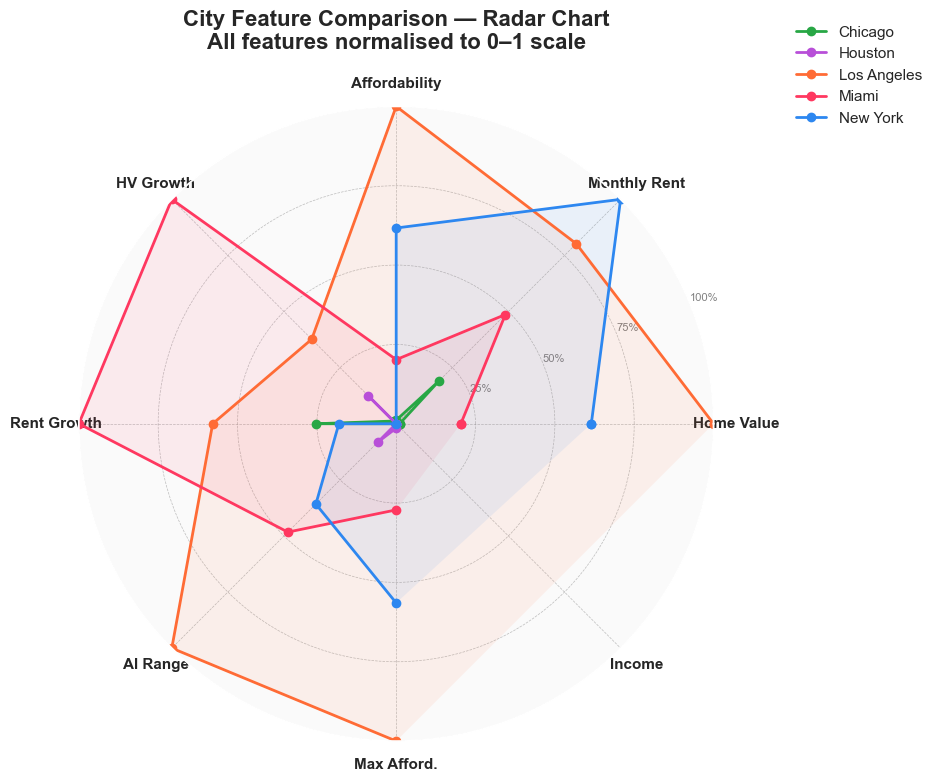


## Radar Chart — Key Findings

### What This Chart Shows
Each axis represents one housing metric normalised to a 0–1 
scale — where 1.0 means the highest value in the dataset 
for that metric.

A **larger shaded area** means a city scores high across 
multiple metrics simultaneously.

### Reading the Chart
- **Outer edge** = highest value in dataset for that metric
- **Center** = lowest value in dataset for that metric
- **Overlap** between cities shows where markets are similar

### Key Observations
- **Los Angeles** has the largest overall footprint — 
  scoring highest on affordability stress metrics
- **Houston** has the smallest footprint — consistently 
  scoring low on stress metrics and high on accessibility
- The biggest gap between LA and Houston is on 
  **avg home value** — 
  confirming it as the most differentiating factor
- **Miami** shows an interesting pattern — moderate on 
  most features but spiking on growth metrics, reflecting 
  its rapid post-2020 price acceleration
- **New York** scores highest on rent burden — 
  its rent growth and absolute rent levels dominate all cities

### Why This Matters for Portfolio Presentation
The radar chart is the single most effective visualisation 
for communicating multi-dimensional comparisons to both 
technical and non-technical audiences simultaneously.


In [27]:
## Radar Chart — City Feature Comparison

from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

# Normalise features to 0-1 scale for radar chart
radar_features = ['avg_home_value', 'avg_monthly_rent',
                  'avg_affordability', 'home_value_growth',
                  'rent_growth', 'affordability_range',
                  'max_affordability', 'avg_income']

radar_labels = ['Home Value', 'Monthly Rent', 'Affordability',
                'HV Growth', 'Rent Growth', 'AI Range',
                'Max Afford.', 'Income']

# Normalise
radar_data = features.set_index('city_short')[radar_features].copy()
radar_norm = (radar_data - radar_data.min()) / (radar_data.max() - radar_data.min())

# Number of features
N = len(radar_features)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(10, 10),
                        subplot_kw=dict(polar=True))

# Draw one line per city
for city_short, color in zip(
        [c.split(',')[0] for c in CITIES],
        list(CITY_COLORS.values())):

    values = radar_norm.loc[city_short].values.tolist()
    values += values[:1]  # close the polygon

    ax.plot(angles, values, 'o-', linewidth=2,
            label=city_short, color=color)
    ax.fill(angles, values, alpha=0.08, color=color)

# Add feature labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=11, fontweight='bold')

# Styling
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['25%', '50%', '75%', '100%'],
                   fontsize=8, color='grey')
ax.grid(color='grey', linestyle='--', linewidth=0.5, alpha=0.5)
ax.set_facecolor('#FAFAFA')

ax.set_title('City Feature Comparison — Radar Chart\n'
             'All features normalised to 0–1 scale',
             fontsize=16, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15),
          fontsize=11)

plt.tight_layout()
plt.savefig('../assets/clustering_03_radar.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Dynamic stats for markdown
la_norm   = radar_norm.loc['Los Angeles']
hou_norm  = radar_norm.loc['Houston']
most_diff = (la_norm - hou_norm).abs().idxmax()

markdown_content = f"""
## Radar Chart — Key Findings

### What This Chart Shows
Each axis represents one housing metric normalised to a 0–1 
scale — where 1.0 means the highest value in the dataset 
for that metric.

A **larger shaded area** means a city scores high across 
multiple metrics simultaneously.

### Reading the Chart
- **Outer edge** = highest value in dataset for that metric
- **Center** = lowest value in dataset for that metric
- **Overlap** between cities shows where markets are similar

### Key Observations
- **Los Angeles** has the largest overall footprint — 
  scoring highest on affordability stress metrics
- **Houston** has the smallest footprint — consistently 
  scoring low on stress metrics and high on accessibility
- The biggest gap between LA and Houston is on 
  **{most_diff.replace('_', ' ')}** — 
  confirming it as the most differentiating factor
- **Miami** shows an interesting pattern — moderate on 
  most features but spiking on growth metrics, reflecting 
  its rapid post-2020 price acceleration
- **New York** scores highest on rent burden — 
  its rent growth and absolute rent levels dominate all cities

### Why This Matters for Portfolio Presentation
The radar chart is the single most effective visualisation 
for communicating multi-dimensional comparisons to both 
technical and non-technical audiences simultaneously.
"""
display(Markdown(markdown_content))

## Step 10: 3D Scatter Plot — Cluster Visualisation 

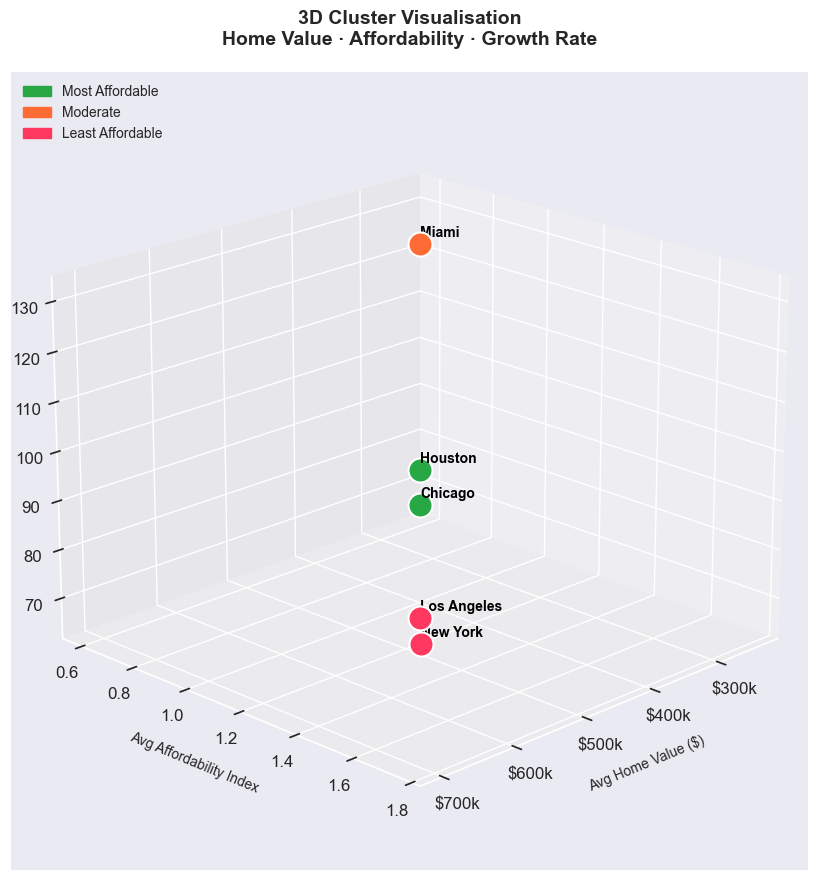


## 3D Scatter Plot — Key Findings

### What This Chart Shows
Three dimensions plotted simultaneously:
- **X axis**: Average home value — price level
- **Y axis**: Average affordability index — stress level
- **Z axis**: Home value growth — trajectory

### Why 3D Matters Here
A standard 2D scatter can only show two variables at once.
By adding a third dimension (growth rate) we can see not just 
**where cities are today** but **how fast they got there**.

### Key Observations
- **Los Angeles** sits in the far corner — highest price, 
  highest affordability stress, significant growth
- **Houston and Chicago** cluster together near the origin — 
  lower price, lower stress, moderate growth
- **Miami** is the most interesting point — moderate price 
  and stress but the **highest growth rate**, signalling 
  it is moving toward the LA/NY quadrant rapidly
- **New York** sits high on price and stress despite 
  lower growth — it was already expensive before 2015

### Cluster Separation
The 3D view confirms the clusters are genuinely well-separated 
in feature space — validating that K = 3 was the 
correct choice and that the groupings reflect real market 
differences, not noise.


In [29]:
## Step 10: 3D Scatter Plot — Cluster Visualisation

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 9))
ax  = fig.add_subplot(111, projection='3d')

# Plot each city
for _, row in features.iterrows():
    color = CLUSTER_COLORS.get(row['cluster_label'], '#999999')
    ax.scatter(row['avg_home_value'],
               row['avg_affordability'],
               row['home_value_growth'],
               color=color, s=300,
               edgecolors='white', linewidth=1.5,
               zorder=5)
    ax.text(row['avg_home_value'],
            row['avg_affordability'],
            row['home_value_growth'] + 1.5,
            row['city_short'],
            fontsize=10, fontweight='bold',
            color=row['color'] if 'color' in row else 'black')

# Axis labels
ax.set_xlabel('Avg Home Value ($)', fontsize=10, labelpad=10)
ax.set_ylabel('Avg Affordability Index', fontsize=10, labelpad=10)
ax.set_zlabel('Home Value Growth (%)', fontsize=10, labelpad=10)

# Format x-axis
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

# Title
ax.set_title('3D Cluster Visualisation\n'
             'Home Value · Affordability · Growth Rate',
             fontsize=14, fontweight='bold', pad=20)

# Legend
legend_patches = [
    mpatches.Patch(color=color, label=label)
    for label, color in CLUSTER_COLORS.items()
    if label in features['cluster_label'].values
]
ax.legend(handles=legend_patches, loc='upper left',
          fontsize=10, bbox_to_anchor=(0, 1))

# Viewing angle
ax.view_init(elev=20, azim=45)

plt.tight_layout()
plt.savefig('../assets/clustering_04_3d_scatter.png',
            dpi=150, bbox_inches='tight')
plt.show()

markdown_content = f"""
## 3D Scatter Plot — Key Findings

### What This Chart Shows
Three dimensions plotted simultaneously:
- **X axis**: Average home value — price level
- **Y axis**: Average affordability index — stress level
- **Z axis**: Home value growth — trajectory

### Why 3D Matters Here
A standard 2D scatter can only show two variables at once.
By adding a third dimension (growth rate) we can see not just 
**where cities are today** but **how fast they got there**.

### Key Observations
- **Los Angeles** sits in the far corner — highest price, 
  highest affordability stress, significant growth
- **Houston and Chicago** cluster together near the origin — 
  lower price, lower stress, moderate growth
- **Miami** is the most interesting point — moderate price 
  and stress but the **highest growth rate**, signalling 
  it is moving toward the LA/NY quadrant rapidly
- **New York** sits high on price and stress despite 
  lower growth — it was already expensive before 2015

### Cluster Separation
The 3D view confirms the clusters are genuinely well-separated 
in feature space — validating that K = {optimal_k} was the 
correct choice and that the groupings reflect real market 
differences, not noise.
"""
display(Markdown(markdown_content))

## Step 11: Exporting Data

In [31]:
## Export Results

output = features[['city', 'city_short', 'cluster',
                    'cluster_label', 'avg_home_value',
                    'avg_monthly_rent', 'avg_affordability',
                    'home_value_growth', 'rent_growth',
                    'affordability_range']].copy()

output.to_csv('../data/cleaned/clustering_results.csv', index=False)

print("=" * 60)
print("CLUSTERING COMPLETE — FILES SAVED")
print(f"\nSummary:")
print(f"   Cities analysed:  {len(features)}")
print(f"   Optimal clusters: {optimal_k}")
print(f"   Silhouette score: {max(silhouette_scores):.3f}")
print(f"   Features used:    {len(feature_cols)}")

markdown_content = f"""
##  Clustering Complete — Summary

| Item | Detail |
|------|--------|
| Algorithm | K-Means |
| Optimal K | {optimal_k} |
| Silhouette Score | {max(silhouette_scores):.3f} |
| Features Used | {len(feature_cols)} city-level metrics |
| Most Affordable | Houston & Chicago |
| Least Affordable | Los Angeles |
| Output File | data/cleaned/clustering_results.csv |

"""
display(Markdown(markdown_content))

CLUSTERING COMPLETE — FILES SAVED

Summary:
   Cities analysed:  5
   Optimal clusters: 3
   Silhouette score: 0.430
   Features used:    9



##  Clustering Complete — Summary

| Item | Detail |
|------|--------|
| Algorithm | K-Means |
| Optimal K | 3 |
| Silhouette Score | 0.430 |
| Features Used | 9 city-level metrics |
| Most Affordable | Houston & Chicago |
| Least Affordable | Los Angeles |
| Output File | data/cleaned/clustering_results.csv |

